HOUSE PRICES - ADVANCED REGRESSION TECHNIQUES


## PREDICTING HOUSE PRICES USING MACHINE LEARNING

### Objectives
- Using the information we have about a house to predict how much that house is likely to sell for.
- To build a machine learning model that can predict the selling price of a house based on its features, such as its quality, size, location, garage, number of rooms, and other characteristics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set() #default syle for seaborn 


pd.set_option("display.max_columns", None)

#scikit-learn library
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor


from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import os


import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv(r"C:\Users\FAVOUR AWOFIRANYE\Downloads\house-prices-advanced-regression-techniques\train.csv")
df_copy = df.copy()
df_copy

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

UNDERSTANDING DATASET
| Feature        | Meaning                                            |
| -------------- | -------------------------------------------------- |
| LotFrontage  | Length of the property's frontage along the street |
| LotArea      | Size of the land/lot                               |
| OverallQual  | Overall quality of the house                       |
| OverallCond  | Overall condition of the house                     |
| YearBuilt    | Year the house was originally built                |
| YearRemodAdd | Year it was remodeled                              |
| GrLivArea    | Above-ground living area                           |
| BedroomAbvGr | Number of bedrooms above ground                    |
| FullBath     | Number of full bathrooms                           |
| GarageCars   | Garage capacity in cars                            |
| GarageArea   | Garage size                                        |
| TotalBsmtSF  | Total basement area                                |
| SalePrice    | Actual selling price of the house                  |


In [3]:
#first 5 columns
df_copy.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_copy.shape

(1460, 81)

In [5]:
#checking for null values
df_copy.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
df_copy["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [7]:
df_copy.groupby("Neighborhood")["LotFrontage"].agg(["count", "median"])

,count,median
Neighborhood,,
Blmngtn,14,43.0
Blueste,2,24.0
BrDale,16,21.0
BrkSide,51,52.0
ClearCr,13,80.0
CollgCr,126,70.0
Crawfor,41,74.0
Edwards,92,65.5
Gilbert,49,65.0


In [8]:
#fill every house without LotFront... with the median (64) since the mean and median are close
df_copy["LotFrontage"] = df_copy["LotFrontage"].fillna(df_copy["LotFrontage"].median())
df_copy["LotFrontage"]

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [9]:
df_copy["LotFrontage"].isna().sum()

np.int64(0)

In [64]:
df_copy.isnull().sum().sum()

np.int64(89)

In [65]:
df_copy.isna().sum()[df_copy.isna().sum() > 0]

MasVnrArea      8
GarageYrBlt    81
dtype: int64

In [66]:
#fill every house without MasVnrArea... with the median (64) since the mean and median are close
df_copy["MasVnrArea"] = df_copy["MasVnrArea"].fillna(df_copy["MasVnrArea"].median())
df_copy["MasVnrArea"]

0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64

In [67]:
df_copy["MasVnrArea"].isna().sum()

np.int64(0)

In [68]:
#fill every house without LotFront... with the median (64) since the mean and median are close
df_copy["GarageYrBlt"] = df_copy["GarageYrBlt"].fillna(df_copy["GarageYrBlt"].median())
df_copy["GarageYrBlt"]

0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
         ...  
1455    1999.0
1456    1978.0
1457    1941.0
1458    1950.0
1459    1965.0
Name: GarageYrBlt, Length: 1460, dtype: float64

In [69]:
df_copy.isnull().sum().sum()

np.int64(0)

The null values has been replaced with the median value

In [10]:
#checking for duplicates
df_copy.duplicated().sum()

np.int64(0)

The dataset has no duplicate

In [11]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
#numerical columns
numerical_cols = df_copy.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [13]:
#categorical columns
categorical_cols = df_copy.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [14]:
#checking the saleprice
df_copy["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

The mean is higher than the median .
This suggests SalePrice is right-skewed; there are some expensive houses pulling the average upward.

The maximum of $755,000 compared with the median of $163,000 also shows that there are some very high-priced houses.

In [15]:
df_copy["Street"].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [16]:
df_copy["HouseStyle"].value_counts()

HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

In [17]:
df_copy["SaleType"].value_counts()

SaleType
WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: count, dtype: int64

In [17]:
df_copy["SaleCondition"].value_counts()

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

#### Data Visualization

#### Numerical features

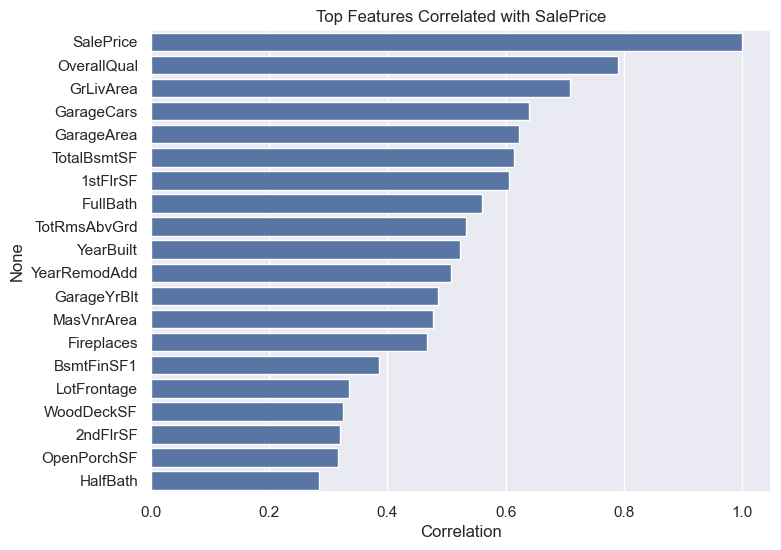

In [18]:
#correlation between numerical features
corr = df_copy.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr.head(20).values, y=corr.head(20).index)
plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.show()

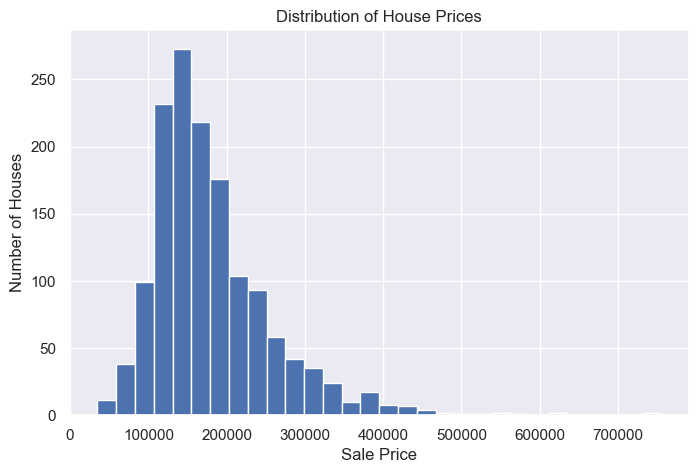

In [19]:
#Sales price vs number of houses
plt.figure(figsize=(8,5))
plt.hist(df_copy["SalePrice"], bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

Majority of the houses are in the range of $100000 - $200000

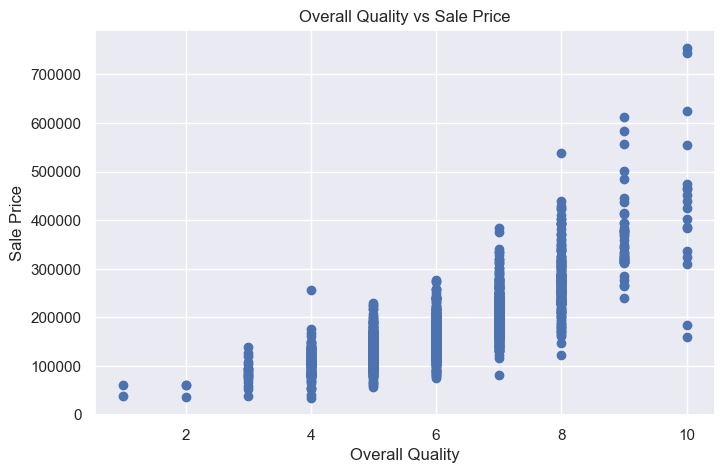

In [20]:
#overall quality vs house prices
plt.figure(figsize=(8,5))
plt.scatter(df_copy["OverallQual"], df_copy["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")
plt.show()

Houses with high quality has higher prices.
Overall quality has a strong effect on houses prices

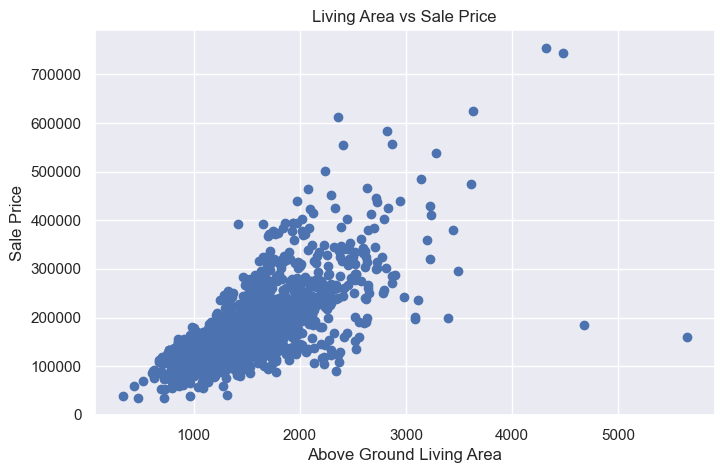

In [21]:
#Living area vs sales price
plt.figure(figsize=(8,5))
plt.scatter(df_copy["GrLivArea"], df_copy["SalePrice"])
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")
plt.show()

Sale price generally increases as the living area increases. However, the relationship isn't perfect because houses with similar living areas can have different prices. We can also see a few unusual houses with very large living areas but relatively low prices which might be potential outliers

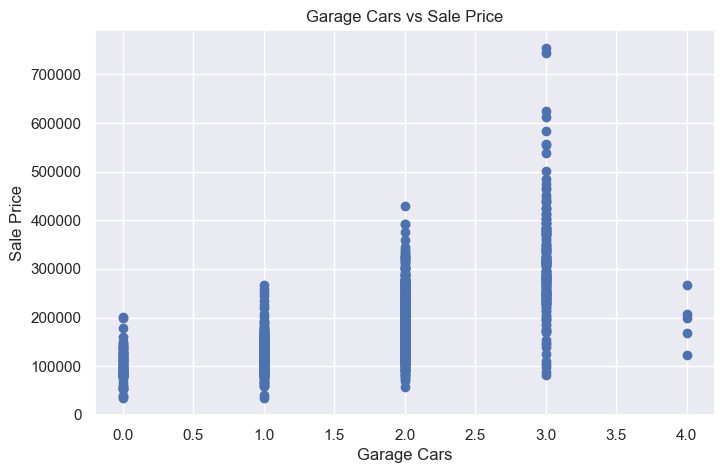

In [22]:
#Garage cars vs Sales price
plt.figure(figsize=(8,5))
plt.scatter(df_copy["GarageCars"], df_copy["SalePrice"])
plt.xlabel("Garage Cars")
plt.ylabel("Sale Price")
plt.title("Garage Cars vs Sale Price")
plt.show()

Sale prices generally increase as the number of garage spaces increases. Houses with 2 or 3 garage spaces tend to be more expensive, while houses with fewer garage spaces are generally cheaper. There’s still a lot of variation, so garage space is not the only factor affecting house prices.

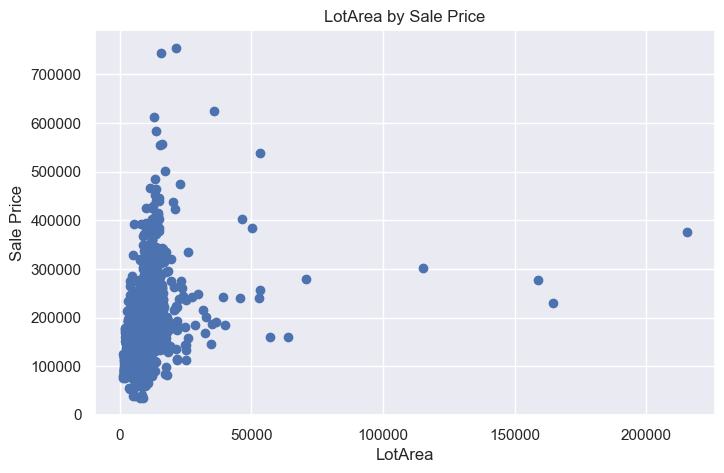

In [23]:
#Land/plot size  vs Sales price
plt.figure(figsize=(8,5))
plt.scatter(df_copy["LotArea"], df_copy["SalePrice"])
plt.xlabel("LotArea")
plt.ylabel("Sale Price")
plt.title("LotArea by Sale Price")
plt.show()

Houses with smaller land plots has higher prices

#### Categorical features

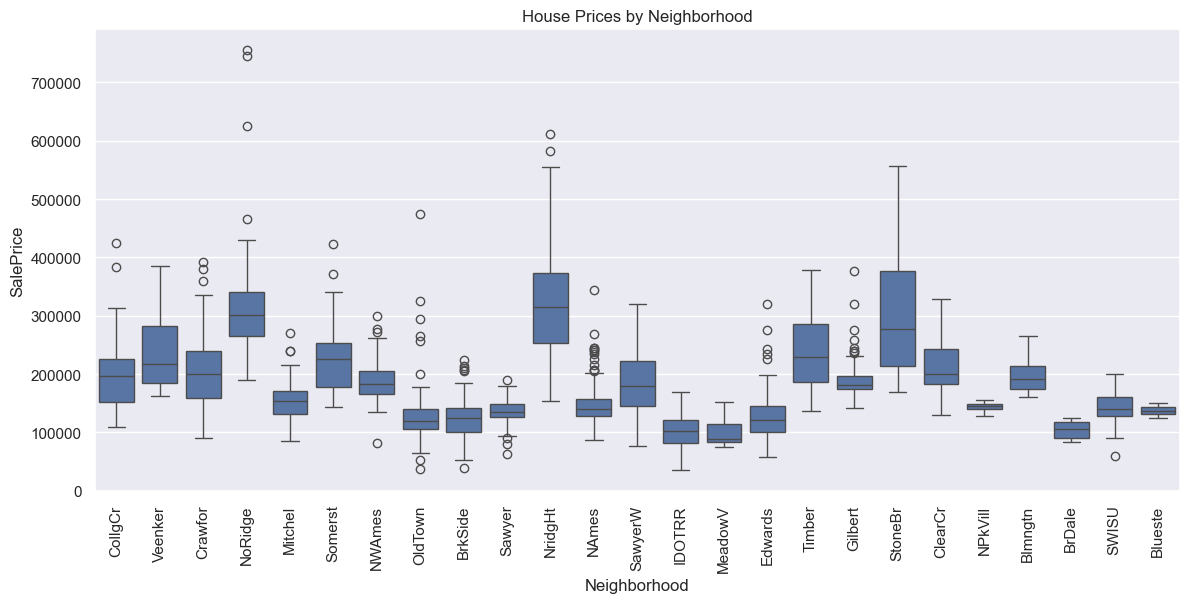

In [24]:
#Neighborhood vs sales prices
plt.figure(figsize=(14,6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=df_copy)
plt.xticks(rotation=90)
plt.title("House Prices by Neighborhood")
plt.show()

Houses in NoRidge has higher prices

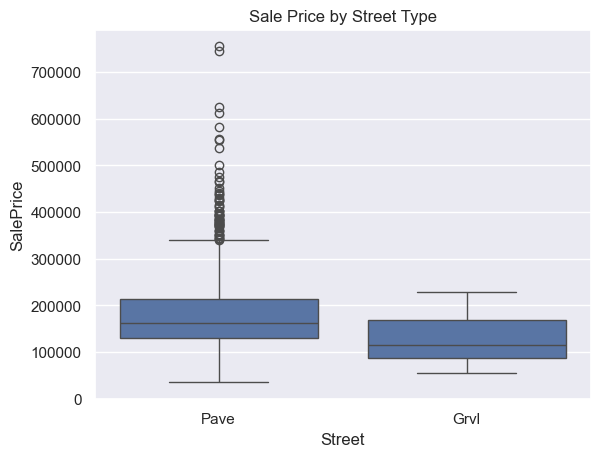

In [25]:
#street vs sales price
sns.boxplot(x="Street", y="SalePrice", data=df_copy)
plt.title("Sale Price by Street Type")
plt.show()

Houses with paved street has higher prices

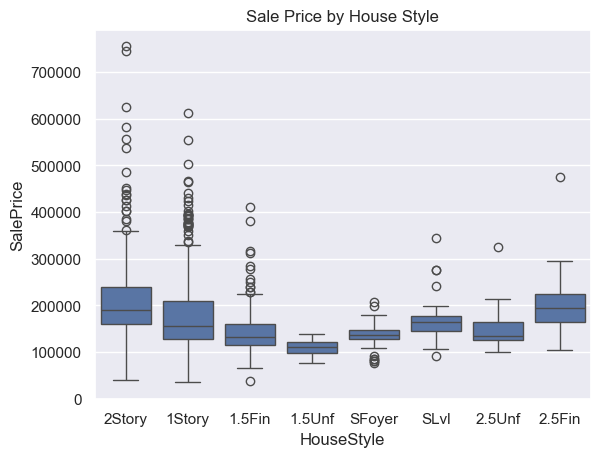

In [26]:
#house style vs sales price
sns.boxplot(x="HouseStyle", y="SalePrice", data=df_copy)
plt.title("Sale Price by House Style")
plt.show()

2 story houses has higher prices

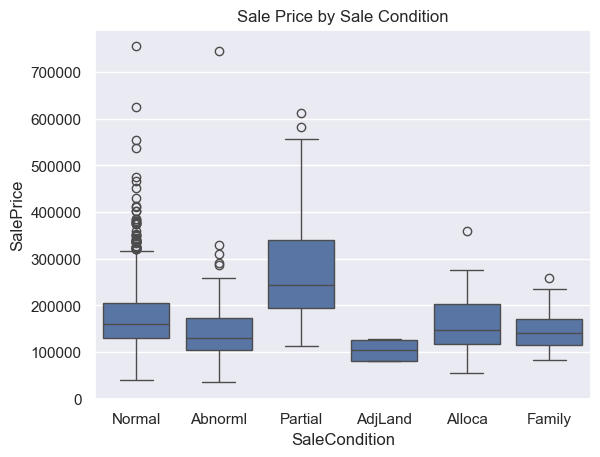

In [27]:
#Sales condition
sns.boxplot(x="SaleCondition", y="SalePrice", data=df_copy)
plt.title("Sale Price by Sale Condition")
plt.show()

Most of the sales are normal

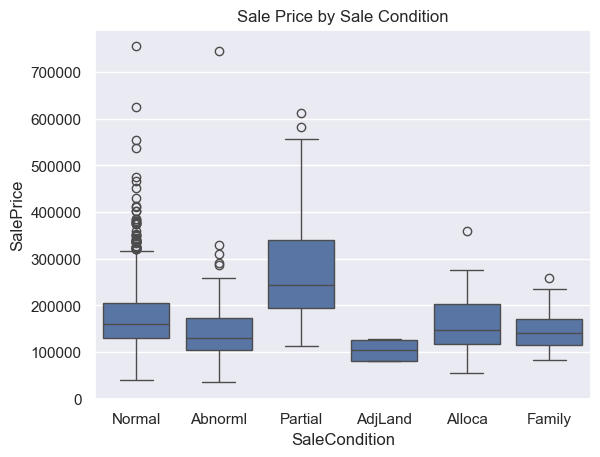

In [28]:
#sales condition
sns.boxplot(x="SaleCondition", y="SalePrice", data=df_copy)
plt.title("Sale Price by Sale Condition")
plt.show()

In [29]:
#heatmap for numerical features
corr = df_copy.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

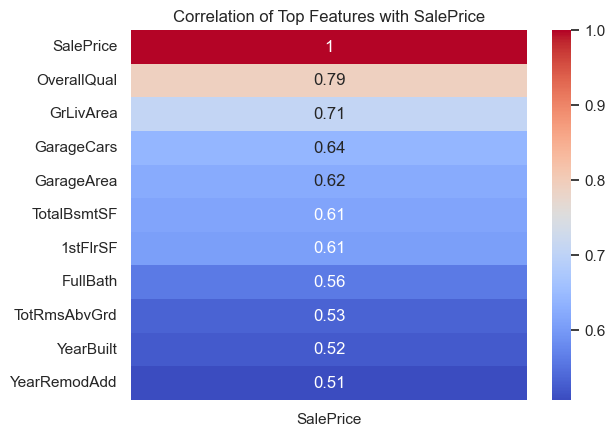

In [30]:
top_corr = corr.abs().sort_values(ascending=False).head(11)

sns.heatmap(
    df_copy[top_corr.index].corr()[["SalePrice"]],
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Top Features with SalePrice")
plt.show()

Some features are more closely related to the house price than others. OverallQual stands out because it has a really strong positive correlation with SalePrice. GrLivArea also has a strong relationship, which makes sense because bigger living spaces tend to be more expensive. The other features also show positive relationships, but they aren't as strong. This shows which features are likely to be more useful when predicting the price of a house.

### Feature Engineering

#### Objectives
- Transform categorical variables into numerical representations through encoding
- Ensure numerical features are on a comparable scale
- Prepare the data for machine learning
- Enhance prediction accuracy



In [31]:
#Total floor surface
df_copy["TotalSF"] = df_copy["TotalBsmtSF"] + df_copy["1stFlrSF"] + df_copy["2ndFlrSF"]
df_copy[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


In [32]:
#Total Bathroom
#full bathrooms as 1, half as 0.5
df_copy["TotalBathrooms"] = (
    df["FullBath"] +
    0.5 * df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5 * df["BsmtHalfBath"]
)
df_copy[[
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotalBathrooms"
]].head()

,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,TotalBathrooms
0,2,1,1,0,3.5
1,2,0,0,1,2.5
2,2,1,1,0,3.5
3,1,0,1,0,2.0
4,2,1,1,0,3.5


In [33]:
#Total Porch
df_copy["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
    + df["WoodDeckSF"]
)
df_copy[[
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "WoodDeckSF",
    "TotalPorchSF"
]].head()

,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,WoodDeckSF,TotalPorchSF
0,61,0,0,0,0,61
1,0,0,0,0,298,298
2,42,0,0,0,0,42
3,35,272,0,0,0,307
4,84,0,0,0,192,276


In [34]:
#House age
df_copy["HouseAge"] = df_copy["YrSold"] - df_copy["YearBuilt"]
df_copy[["YearBuilt", "YrSold", "HouseAge"]].head()

,YearBuilt,YrSold,HouseAge
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


In [35]:
#model year
df_copy["YearsSinceRemodel"] = df_copy["YrSold"] - df_copy["YearRemodAdd"]
df_copy[["YearRemodAdd", "YrSold", "YearsSinceRemodel"]].head()

,YearRemodAdd,YrSold,YearsSinceRemodel
0,2003,2008,5
1,1976,2007,31
2,2002,2008,6
3,1970,2006,36
4,2000,2008,8


In [36]:
df_copy["HasGarage"] = (df_copy["GarageArea"] > 0).astype(int)
df_copy[["GarageArea", "GarageCars", "HasGarage"]].head()

,GarageArea,GarageCars,HasGarage
0,548,2,1
1,460,2,1
2,608,2,1
3,642,3,1
4,836,3,1


In [37]:
df_copy["HasGarage"].value_counts()

HasGarage
1    1379
0      81
Name: count, dtype: int64

In [38]:
df_copy[[
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HasGarage",
    "HouseAge",
    "YearsSinceRemodel"
]].describe()

,TotalSF,TotalBathrooms,TotalPorchSF,HasGarage,HouseAge,YearsSinceRemodel
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,2567.048630,2.210616,181.329452,0.944521,36.547945,22.950000
std,821.714421,0.785399,156.656097,0.228992,30.250152,20.640653
min,334.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,2009.500000,2.000000,45.000000,1.000000,8.000000,4.000000
50%,2474.000000,2.000000,164.000000,1.000000,35.000000,14.000000
75%,3004.000000,2.500000,266.000000,1.000000,54.000000,41.000000
max,11752.000000,6.000000,1027.000000,1.000000,136.000000,60.000000


In [39]:
df_copy[[
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HasGarage",
    "HouseAge",
    "YearsSinceRemodel"
]].head()

,TotalSF,TotalBathrooms,TotalPorchSF,HasGarage,HouseAge,YearsSinceRemodel
0,2566,3.5,61,1,5,5
1,2524,2.5,298,1,31,31
2,2706,3.5,42,1,7,6
3,2473,2.0,307,1,91,36
4,3343,3.5,276,1,8,8


In [40]:
#checking if the new features have a relationship with sales price
Engineered_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HasGarage",
    "HouseAge",
    "YearsSinceRemodel"
]

df_copy[Engineered_features + ["SalePrice"]].corr()["SalePrice"].sort_values(ascending=False)

SalePrice            1.000000
TotalSF              0.782260
TotalBathrooms       0.631731
TotalPorchSF         0.390993
HasGarage            0.236832
YearsSinceRemodel   -0.509079
HouseAge            -0.523350
Name: SalePrice, dtype: float64

TotalSF stood out the most, which makes sense because bigger houses usually cost more. Bathrooms also had a strong relationship with price. I noticed that house age and the number of years since the last remodel had negative relationships, meaning older houses or houses that haven't been remodeled recently tend to sell for less. So this gives me an idea of which of the new features might be useful for my model.

#### One-Hot Encoder

In [70]:
df_copy = pd.get_dummies(df_copy, drop_first=True)

In [71]:
df_copy.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=252)

In [72]:
df_copy.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,YearsSinceRemodel,HasGarage,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,200

In [73]:
df_copy.dtypes

Id                         int64
MSSubClass                 int64
LotFrontage              float64
LotArea                    int64
OverallQual                int64
                          ...   
SaleCondition_AdjLand       bool
SaleCondition_Alloca        bool
SaleCondition_Family        bool
SaleCondition_Normal        bool
SaleCondition_Partial       bool
Length: 252, dtype: object

- The first category is dropped because the remaining columns can tell us which category it belongs to.
- Each category gets its own column.
- 1 means the house belongs to that category.
- 0 means the house doesn't belong to that category.


### Train-test Split
- Dividing a dataset into two separate parts -  a training set and a testing set.
- The training set is used to teach the machine learning model how to recognize patterns and relationships in the data.
- The testing set is used to evaluate the model's performance on unseen data and determine how well it can make predictions.

In [74]:
#X is the independent variable - features
#y is the dependent variable - target

x = df_copy.drop("SalePrice", axis=1)
y = df_copy["SalePrice"]

In [75]:
#80:20 ratio
#80 for training set, 20 for testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

Why do we split?

It's because we don't want to test the model using the same houses it already learned from.
Learn from 80%,test on the remaining 20% - see how well it performs on houses it hasn't seen before.


In [76]:
x_train.shape

(1168, 251)

In [77]:
x_test.shape

(292, 251)

In [78]:
x_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,YearsSinceRemodel,HasGarage,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,255,20,70.0,8400,5,6,1957,1957,0.0,922,0,392,1314,1314,0,0,1314,1,0,1,0,3,1,5,0,1957.0,1,29

In [79]:
x_train.select_dtypes(include="object").columns

Index([], dtype='object')

#### Feature Scaling

In [81]:
#Standard Scaler (Mean=0, std=1)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [82]:
x_train_scaled

array([[-1.11928402, -0.8667643 , -0.00419319, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.79046412,  0.07410996, -0.49395768, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.21615189, -0.63154574, -0.13776532, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [ 1.32669882, -0.8667643 , -0.44943363, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.30597137, -0.16110861, -0.67205386, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.93157852,  1.48542135, -0.76110194, ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(1168, 251))

In [83]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_train_scaled

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,YearsSinceRemodel,HasGarage,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.119284,-0.866764,-0.004193,-0.212896,-0.820445,0.372217,-0.455469,-1.346063,-0.597889,1.03

In [84]:
x_test_scaled

array([[ 0.38123238, -0.8667643 , -0.00419319, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.88218848,  0.07410996,  1.24248005, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.74533088, -0.63154574, -0.62752981, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [ 0.16956079,  0.07410996, -0.3158615 , ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.18557711,  0.30932853, -0.44943363, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.01859174, -0.8667643 , -0.00419319, ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(292, 251))

In [85]:
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)
x_test_scaled

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,YearsSinceRemodel,HasGarage,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.381232,-0.866764,-0.004193,-0.211594,-0.088934,2.165000,-0.259789,0.873470,-0.597889,0.4728

In [86]:
x_train.isnull().sum().sum()

np.int64(0)

In [87]:
missing = x_train.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

### Model Training

In [88]:
#Linear Regression: assumes that there is a linear relationship between X and y
linreg = LinearRegression() #create an instance of the model
#fit the instance to the training set
linreg.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
#evaluate on the test set
linpreds = linreg.predict(x_test_scaled)
linpreds

array([ 159094.06062021,  347605.97709841,   84032.08398727,
        175204.98904114,  327558.01926925,   69099.44698104,
        232862.44255263,  146952.85781501,   64394.80167914,
        150599.34818619,  142796.03928088,  103678.61844885,
         80248.90618868,  218972.07225868,  172908.8540637 ,
        131809.12116049,  185660.72760981,  126821.88812147,
        132597.79137821,  214797.34981461,  162565.73890653,
        204256.43821857,  171774.20893161,  127031.09913121,
        198845.14638629,  136815.20768414,  193040.98846375,
        103189.4195242 ,  175595.75981963,  203782.53278343,
        156522.247854  ,  277123.92517058,  243917.87730242,
        108680.22403896,  238869.84389924,  148313.56344803,
        134663.98588589,  200540.0767506 ,  310010.48865096,
        122579.92436461,  119326.15524652,  218410.05048221,
        101339.31824676,  370445.23258422,  130537.29557502,
        135757.54015226,   93973.51919697,  143033.69027197,
        419486.84434527,

In [90]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": linpreds
})

comparison.head(10)

,Actual,Predicted
892,154500,159094.060620
1105,325000,347605.977098
413,115000,84032.083987
522,159000,175204.989041
1036,315500,327558.019269
614,75500,69099.446981
218,311500,232862.442553
1160,146000,146952.857815
649,84500,64394.801679
887,135500,150599.348186


In [91]:
mae = mean_absolute_error(y_test, linpreds)
rmse = mean_squared_error(y_test, linpreds) ** 0.5
r2 = r2_score(y_test, linpreds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 20503.68489401232
RMSE: 49409.422620711106
R² Score: 0.6817226571896591


#### Random Forest

In [92]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [93]:
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [94]:
rf_pred = rf.predict(x_test)

In [95]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

MAE: 18120.860890410957
RMSE: 30386.00780589947
R² Score: 0.879625788338045


In [96]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred
})

comparison.head(10)

,Actual,Predicted
892,154500,138777.75
1105,325000,346157.97
413,115000,111584.54
522,159000,156320.50
1036,315500,322302.28
614,75500,85434.50
218,311500,203423.58
1160,146000,151543.29
649,84500,86718.50
887,135500,131568.62


In [97]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression": [mae, rmse, r2],
    "Random Forest": [rf_mae, rf_rmse, rf_r2]
})

comparison

,Metric,Linear Regression,Random Forest
0,MAE,20503.684894,18120.860890
1,RMSE,49409.422621,30386.007806
2,R² Score,0.681723,0.879626


#### Gradient Boosting

In [98]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

In [99]:
gbr.fit(x_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [100]:
gbr_pred = gbr.predict(x_test)

In [101]:
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = mean_squared_error(y_test, gbr_pred) ** 0.5
gbr_r2 = r2_score(y_test, gbr_pred)

print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)
print("R² Score:", gbr_r2)

MAE: 16601.947389219902
RMSE: 27194.688204866423
R² Score: 0.9035828403403575


In [102]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": gbr_pred
})

comparison.head(10)

,Actual,Predicted
892,154500,140897.654649
1105,325000,338102.366931
413,115000,116873.558424
522,159000,146846.876106
1036,315500,322474.359819
614,75500,84584.891879
218,311500,214690.753391
1160,146000,150816.379558
649,84500,83796.377198
887,135500,138797.004075


In [103]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression": [mae, rmse, r2],
    "Random Forest": [rf_mae, rf_rmse, rf_r2],
    "Gradient Boosting": [gbr_mae, gbr_rmse, gbr_r2]
})

comparison

,Metric,Linear Regression,Random Forest,Gradient Boosting
0,MAE,20503.684894,18120.860890,16601.947389
1,RMSE,49409.422621,30386.007806,27194.688205
2,R² Score,0.681723,0.879626,0.903583


In [104]:
joblib.dump(gbr, "house_price_model.pkl")

['house_price_model.pkl']

In [105]:
joblib.dump(x_train.columns.tolist(), "house_price_features.pkl")

['house_price_features.pkl']

In [106]:
print(os.path.exists("house_price_model.pkl"))
print(os.path.exists("house_price_features.pkl"))

True
True


In [107]:
print(df.shape)
print(x_train.shape)
print(x_test.shape)

(1460, 81)
(1168, 251)
(292, 251)


In [108]:
print(x_train.columns[-10:])

Index(['SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object')


In [109]:
loaded_model = joblib.load("house_price_model.pkl")
print(loaded_model)

GradientBoostingRegressor(random_state=42)


In [110]:
test_prediction = loaded_model.predict(x_test.iloc[:1])

print(test_prediction)
print(y_test.iloc[0])

[140897.65464931]
154500


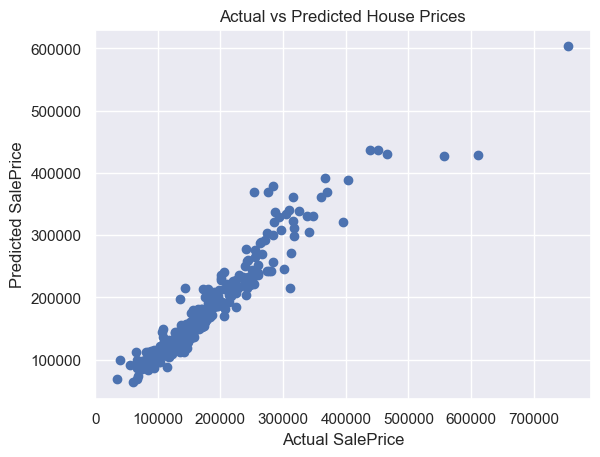

In [111]:
plt.scatter(y_test, gbr_pred)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Model Training Summary

I tested three different regression models to find the one that could predict house prices most accurately. I started with Linear Regression which achieved an R² score of 68.2%. I then tested Random Forest, which performed better with an R² of 88.0%. Finally, I trained a Gradient Boosting model, which gave the best results with an R² score of 90.5%, a MAE of about ₦16,729, and an RMSE of about ₦26,977. Based on these results, Gradient Boosting was selected as the final model because it had the lowest prediction errors and the highest R² score among the models tested.


#### Feature Importance

In [112]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": gbr.feature_importances_
})

In [113]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [114]:
feature_importance.head(10)

,Feature,Importance
37,TotalSF,0.449493
4,OverallQual,0.299491
38,TotalBathrooms,0.026989
26,GarageCars,0.024815
14,2ndFlrSF,0.023521
40,HouseAge,0.021603
9,BsmtFinSF1,0.017813
3,LotArea,0.013128
6,YearBuilt,0.010163
24,Fireplaces,0.009973


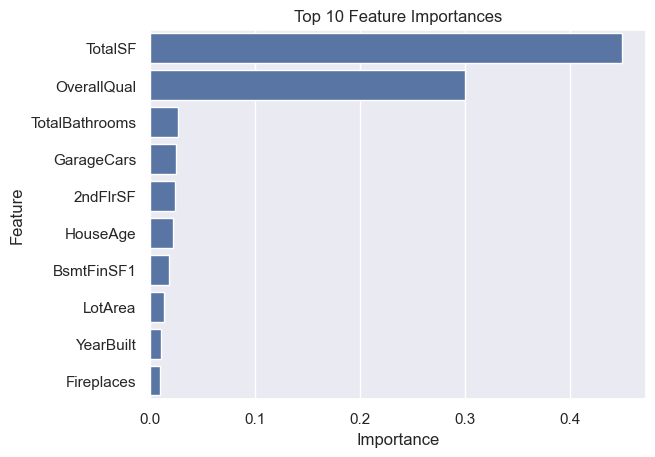

In [115]:
top_features = feature_importance.head(10)
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.show()

Feature importance shows which features the model relied on most when predicting house prices. A higher importance means the feature had a greater influence on the model's predictions, while a lower importance means it contributed less. It tells us how useful a feature was to the model, not whether it increases or decreases the house price.
OverallQual has the highest feature importance which suggest it was the feature the Gradient Boosting model relied on most when predicting house prices.

In [117]:
print(df.shape)
print(df.columns.tolist())

(1460, 81)
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea

In [118]:
df.shape

(1460, 81)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [120]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

#### Conclusion
- The goal of this project was to build a machine learning model that could predict house prices based on different characteristics of the houses. After cleaning and exploring the data, I created additional features that could provide more useful information to the model. I then encoded the categorical variables and prepared the data for modelling.

- I tested three models: Linear Regression, Random Forest, and Gradient Boosting. Gradient Boosting performed the best, achieving an R² score of 0.905, with a MAE of about 16,729 and an RMSE of about 26,977. I also used feature importance to understand which features contributed most to the predictions, with OverallQual being the most important feature.

- Overall, the results show that Gradient Boosting was able to capture the relationships between the house characteristics and their sale prices better than the other models tested.